In [1]:
# Import Required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [14]:
MAX_RUL = 125

# Data Loading
df_train_FD001 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/train_FD001.txt', sep=' ', header=None)
df_train_FD002 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/train_FD002.txt', sep=' ', header=None)
df_train_FD003 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/train_FD003.txt', sep=' ', header=None)
df_train_FD004 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/train_FD004.txt', sep=' ', header=None)

RUL_FD001 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/RUL_FD001.txt', sep=' ', header=None)
RUL_FD002 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/RUL_FD002.txt', sep=' ', header=None)
RUL_FD003 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/RUL_FD003.txt', sep=' ', header=None)
RUL_FD004 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/RUL_FD004.txt', sep=' ', header=None)

test_FD001 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/test_FD001.txt', sep=' ', header=None)
test_FD002 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/test_FD002.txt', sep=' ', header=None)
test_FD003 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/test_FD003.txt', sep=' ', header=None)
test_FD004 = pd.read_csv('/home/jovyan/work/jet_engine_rul/Data/test_FD004.txt', sep=' ', header=None)

# Remove null data (columns 26 and 27)
df_train_FD001 = df_train_FD001.iloc[:, :26]
df_train_FD002 = df_train_FD002.iloc[:, :26]
df_train_FD003 = df_train_FD003.iloc[:, :26]
df_train_FD004 = df_train_FD004.iloc[:, :26]

# Remove null data (columns 26 and 27)
test_FD001 = test_FD001.iloc[:, :26]
test_FD002 = test_FD002.iloc[:, :26]
test_FD003 = test_FD003.iloc[:, :26]
test_FD004 = test_FD004.iloc[:, :26]

RUL_FD001 = RUL_FD001.iloc[:, 0]
RUL_FD002 = RUL_FD002.iloc[:, 0]
RUL_FD003 = RUL_FD003.iloc[:, 0]
RUL_FD004 = RUL_FD004.iloc[:, 0]

# Define column names
columns = ['Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA', 
           'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 
           'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 
           'PCNfR_dmd', 'W31', 'W32']

df_train_FD001.columns = columns
df_train_FD002.columns = columns
df_train_FD003.columns = columns
df_train_FD004.columns = columns

test_FD001.columns = columns
test_FD002.columns = columns
test_FD003.columns = columns
test_FD004.columns = columns

RUL_column = ['RUL']

RUL_FD001.columns = RUL_column
RUL_FD002.columns = RUL_column
RUL_FD003.columns = RUL_column
RUL_FD004.columns = RUL_column

# Uniquify Unit Numbers
df_train_FD002['Unit Number'] += df_train_FD001['Unit Number'].max()
df_train_FD003['Unit Number'] += df_train_FD002['Unit Number'].max()
df_train_FD004['Unit Number'] += df_train_FD003['Unit Number'].max()

test_FD002['Unit Number'] += test_FD001['Unit Number'].max()
test_FD003['Unit Number'] += test_FD002['Unit Number'].max()
test_FD004['Unit Number'] += test_FD003['Unit Number'].max()

# Merge datasets
df_train = pd.concat([df_train_FD001, df_train_FD002, df_train_FD003, df_train_FD004], axis=0)
df_train = df_train.dropna(how='all', axis=1)
df_train = df_train.dropna(subset=['Unit Number', 'Time (Cycles)'])

df_test = pd.concat([test_FD001, test_FD002, test_FD003, test_FD004], axis=0)
df_test = df_test.dropna(how='all', axis=1)
df_test = df_test.dropna(subset=['Unit Number', 'Time (Cycles)'])

df_rul = pd.concat([RUL_FD001, RUL_FD002, RUL_FD003, RUL_FD004], axis=0)

# Cluster operational conditions
df_conditions = df_train[['Altitude', 'Mach Number', 'TRA']]
df_test_conditions = df_test[['Altitude', 'Mach Number', 'TRA']]
scaler = StandardScaler()
df_conditions_scaled = scaler.fit_transform(df_conditions)
df_test_conditions_scaled = scaler.fit_transform(df_test_conditions)

# Perform KMeans clustering for 6 operational conditions
km = KMeans(n_clusters=6, random_state=42)
df_train['Conditions'] = km.fit_predict(df_conditions_scaled)
df_test['Conditions'] = km.fit_predict(df_test_conditions_scaled)

# Calculate RUL for each unit
df_train['Fail Time'] = df_train.groupby('Unit Number')['Time (Cycles)'].transform('max')
df_train['RUL'] = df_train['Fail Time'] - df_train['Time (Cycles)']
df_train = df_train.drop(columns=['Fail Time'])
df_train['RUL'] = df_train['RUL'].apply(lambda x: x if x <= MAX_RUL else MAX_RUL)

print('Data preparation complete!')
print('## Training set ##')
print(f"Dataset shape: {df_train.shape}")
print(f"Number of engines: {df_train['Unit Number'].nunique()}")
print(f"Number of operational conditions: {df_train['Conditions'].nunique()}")
print('## Nasa Test set ##')
print(f"Dataset shape: {df_test.shape}")
print(f"Number of engines: {df_test['Unit Number'].nunique()}")
print(f"Number of operational conditions: {df_test['Conditions'].nunique()}")

Data preparation complete!
## Training set ##
Dataset shape: (160359, 28)
Number of engines: 709
Number of operational conditions: 6
## Nasa Test set ##
Dataset shape: (104897, 27)
Number of engines: 707
Number of operational conditions: 6


Top 10 Features Most Correlated with RUL:
NRc        0.088583
Ps30       0.061080
farB       0.055686
T50        0.047425
htBleed    0.034307
T30        0.034147
Nc         0.026012
BPR        0.019140
T24        0.006703
epr        0.005140
Name: RUL, dtype: float64


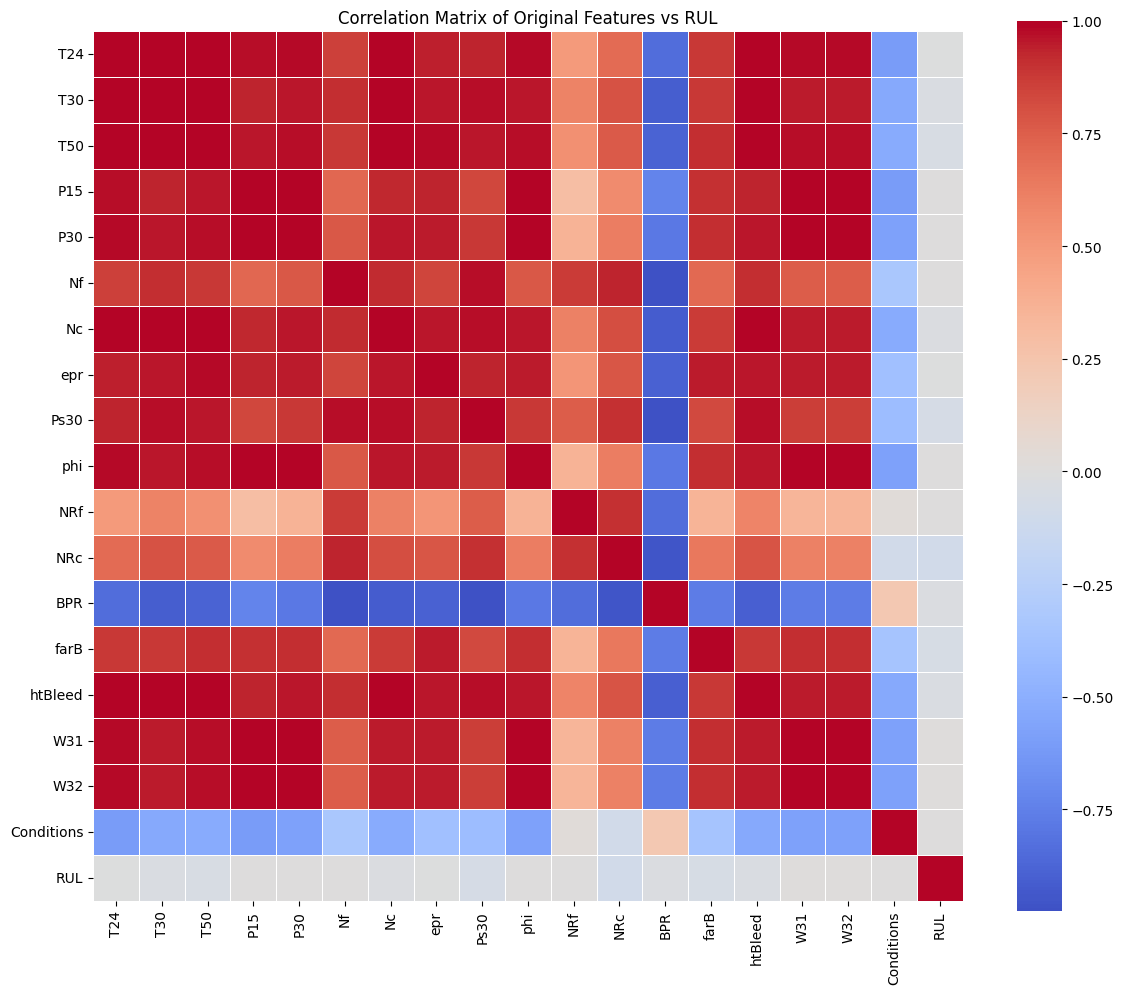


Ranked Features by Correlation with RUL:
 1. NRc       : 0.0886
 2. Ps30      : 0.0611
 3. farB      : 0.0557
 4. T50       : 0.0474
 5. htBleed   : 0.0343
 6. T30       : 0.0341
 7. Nc        : 0.0260
 8. BPR       : 0.0191
 9. T24       : 0.0067
10. epr       : 0.0051
11. W31       : 0.0047
12. W32       : 0.0046
13. NRf       : 0.0010
14. phi       : 0.0006
15. Nf        : 0.0004
16. P15       : 0.0004
17. P30       : 0.0004
18. Conditions: 0.0002


In [3]:
# Create correlation matrix for original features against RUL
def create_correlation_matrix(df):
    '''
    Create correlation matrix of original features against RUL target
    '''
    # Define which sensors to exclude
    not_features = ['Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA']
    weak_features = ['T2', 'P2', 'Nf_dmd', 'PCNfR_dmd']
    irrelevant_features = not_features + weak_features
    feature_names = df.columns
    sensor_names = [name for name in feature_names if name not in irrelevant_features]
    
    # Select only the original sensor data
    original_features = df[sensor_names].copy()
    
    # Calculate correlation matrix
    correlation_matrix = original_features.corr()
    
    # Get correlations with RUL (excluding RUL itself)
    rul_correlations = correlation_matrix['RUL'].drop('RUL').abs().sort_values(ascending=False)
    
    return correlation_matrix, rul_correlations

# Create correlation matrix
corr_matrix, rul_corr = create_correlation_matrix(df_train)

# Display top correlated features
print('Top 10 Features Most Correlated with RUL:')
print(rul_corr.head(10))

# Plot correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Original Features vs RUL')
plt.tight_layout()
plt.show()

# Create ranked list of features
print('\nRanked Features by Correlation with RUL:')
for i, (feature, corr) in enumerate(rul_corr.items(), 1):
    print(f'{i:2d}. {feature:10s}: {corr:.4f}')

In [4]:
def prepare_data(df, selected_sensors, window_size=20, test_set=False):
    '''
    Prepare data with reduced features
    Only uses essential statistical features to reduce computational load
    '''
    features = []
    targets = []
    
    print(f'Selected features for engineering:\n {selected_sensors}')
    engines = sorted(df['Unit Number'].unique())
    
    for engine_num in engines:
        engine_data = df[df['Unit Number'] == engine_num].sort_values('Time (Cycles)')

        print(f'{len(engine_data)} data points in engine {engine_num}')
        # Ensure the engine run has enough data points for the window size
        if len(engine_data) <= window_size:
            continue
            
        # Sliding window approach
        for i in range(len(engine_data) - window_size):
            feature_row = []
            window_data = engine_data.iloc[i:i+window_size]
            
            # Extract statistical features
            for feature in selected_sensors:
                feature_row.extend([
                    window_data[feature].mean(),
                    window_data[feature].std()
                ])
            
            # Extract rate of change (slope) features
            for feature in selected_sensors:
                time_diff = (window_data['Time (Cycles)'].iloc[-1] - 
                             window_data['Time (Cycles)'].iloc[0])
                
                if time_diff != 0:
                    slope = (window_data[feature].iloc[-1] - 
                             window_data[feature].iloc[0]) / time_diff
                else:
                    slope = 0
                feature_row.append(slope)
            
            # Double check that we actually generated features
            if len(feature_row) > 0:
                features.append(feature_row)
                if not test_set:
                    # Target: RUL value at the step immediately following the window
                    target = engine_data.iloc[i + window_size]['RUL']
                    targets.append(target)

    # Convert to arrays safely
    X = np.array(features)
    y = np.array(targets)

    print(f'Number of samples generated: {len(features)}')
    if len(features) > 0:
        print(f'Features Array Shape: {X.shape}') 
    
    return X, y

In [5]:
not_sensor = ['Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA', 'Conditions', 'RUL']
weak_features = ['T2', 'P2', 'Nf_dmd', 'PCNfR_dmd'] # From previous plots
irrelevant_features = not_sensor + weak_features
feature_names = df_train.columns
#selected_sensors = [name for name in feature_names if name not in irrelevant_features]
selected_sensors = rul_corr.keys()

# Prepare data
X, y = prepare_data(df_train, selected_sensors)

Selected features for engineering:
 Index(['NRc', 'Ps30', 'farB', 'T50', 'htBleed', 'T30', 'Nc', 'BPR', 'T24',
       'epr', 'W31', 'W32', 'NRf', 'phi', 'Nf', 'P15', 'P30', 'Conditions'],
      dtype='str')
192 data points in engine 1
287 data points in engine 2
179 data points in engine 3
189 data points in engine 4
269 data points in engine 5
188 data points in engine 6
259 data points in engine 7
150 data points in engine 8
201 data points in engine 9
222 data points in engine 10
240 data points in engine 11
170 data points in engine 12
163 data points in engine 13
180 data points in engine 14
207 data points in engine 15
209 data points in engine 16
276 data points in engine 17
195 data points in engine 18
158 data points in engine 19
234 data points in engine 20
195 data points in engine 21
202 data points in engine 22
168 data points in engine 23
147 data points in engine 24
230 data points in engine 25
199 data points in engine 26
156 data points in engine 27
165 data points in 

In [6]:
# Prepare test data
nasa_test, _ = prepare_data(df_test, selected_sensors, test_set=True)

Selected features for engineering:
 Index(['NRc', 'Ps30', 'farB', 'T50', 'htBleed', 'T30', 'Nc', 'BPR', 'T24',
       'epr', 'W31', 'W32', 'NRf', 'phi', 'Nf', 'P15', 'P30', 'Conditions'],
      dtype='str')
31 data points in engine 1
49 data points in engine 2
126 data points in engine 3
106 data points in engine 4
98 data points in engine 5
105 data points in engine 6
160 data points in engine 7
166 data points in engine 8
55 data points in engine 9
192 data points in engine 10
83 data points in engine 11
217 data points in engine 12
195 data points in engine 13
46 data points in engine 14
76 data points in engine 15
113 data points in engine 16
165 data points in engine 17
133 data points in engine 18
135 data points in engine 19
184 data points in engine 20
148 data points in engine 21
39 data points in engine 22
130 data points in engine 23
186 data points in engine 24
48 data points in engine 25
76 data points in engine 26
140 data points in engine 27
158 data points in engine 28


In [7]:
def rul_score(y_test, y_pred):
    diff = y_pred - y_test
    score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
    return abs(score)

In [8]:
def train_linear_regression(X, y, nasa_test):
    # Split data properly for time series (without shuffling)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_nasa_test_scaled = scaler.transform(nasa_test)
    
    # Train Linear Regression model
    print('--- Training Linear Regression ---')
    
    # Fit model
    linear_regression = LinearRegression()
    linear_regression.fit(X_train_scaled, y_train)
    
    return linear_regression, X_train_scaled, y_test, y_train, X_test_scaled, X_nasa_test_scaled

In [18]:
linear_regression, X_train_scaled, y_test, y_train, X_test_scaled, X_nasa_test_scaled = train_linear_regression(X, y, nasa_test)

# Make predictions
y_train_pred = linear_regression.predict(X_train_scaled)
y_test_pred = linear_regression.predict(X_test_scaled)
y_nasa_test_pred = linear_regression.predict(X_nasa_test_scaled)

unit_ids = df_test['Unit Number'].values
offset = len(unit_ids) - len(y_nasa_test_pred)
diffs = np.diff(unit_ids) != 0
last_indices = np.where(diffs)[0]
last_indices = np.append(last_indices, len(unit_ids) - 1)
adjusted_indices = np.maximum(0, last_indices - offset)
final_predictions = y_nasa_test_pred[adjusted_indices]

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
nasa_test_mse = mean_squared_error(df_rul, final_predictions)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
nasa_test_rmse = np.sqrt(nasa_test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
nasa_test_mae = mean_absolute_error(df_rul, final_predictions)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
nasa_test_r2 = r2_score(df_rul, final_predictions)
train_rul_score = rul_score(y_train, y_train_pred)
test_rul_score = rul_score(y_test, y_test_pred)
nasa_test_rul_score = rul_score(df_rul, final_predictions)

print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Nasa Test RMSE: {nasa_test_rmse:.4f}')
print(f'Train MAE: {train_mae:.4f}')
print(f'Test MAE: {test_mae:.4f}')
print(f'Nasa Test MAE: {nasa_test_mae:.4f}')
print(f'Train R²: {train_r2:.4f}')
print(f'Test R²: {test_r2:.4f}')
print(f'Nasa Test R²: {nasa_test_r2:.4f}')
print(f'Train RUL score: {train_rul_score:.4f}')
print(f'Test RUL score: {test_rul_score:.4f}')
print(f'Nasa Test RUL score: {nasa_test_rul_score:.4f}')

# Store results for later use
results = {
    'model': linear_regression,
    'train_mse': train_mse,
    'test_mse': test_mse,
    'nasa_test_mse': nasa_test_mse,
    'train_rmse': train_rmse,
    'test_rmse': test_rmse,
    'nasa_test_rmse': nasa_test_rmse,
    'train_mae': train_mae,
    'test_mae': test_mae,
    'nasa_test_mae': nasa_test_mae,
    'train_r2': train_r2,
    'test_r2': test_r2,
    'nasa_test_r2': nasa_test_r2,
    'train_rul_score': train_rul_score,
    'test_rul_score': test_rul_score,
    'nasa_test_rul_score': nasa_test_rul_score,
    'y_test': y_test,
    'y_test_pred': y_test_pred,
    'y_nasa_test_pred': final_predictions
}

print('\nModel training completed successfully!')

--- Training Linear Regression ---
Train RMSE: 22.0692
Test RMSE: 22.3308
Nasa Test RMSE: 68.5119
Train MAE: 17.9985
Test MAE: 18.0740
Nasa Test MAE: 54.7477
Train R²: 0.7205
Test R²: 0.7074
Nasa Test R²: -0.7995
Train RUL score: 1654611.0536
Test RUL score: 1222753.4550
Nasa Test RUL score: 998903986.7732

Model training completed successfully!


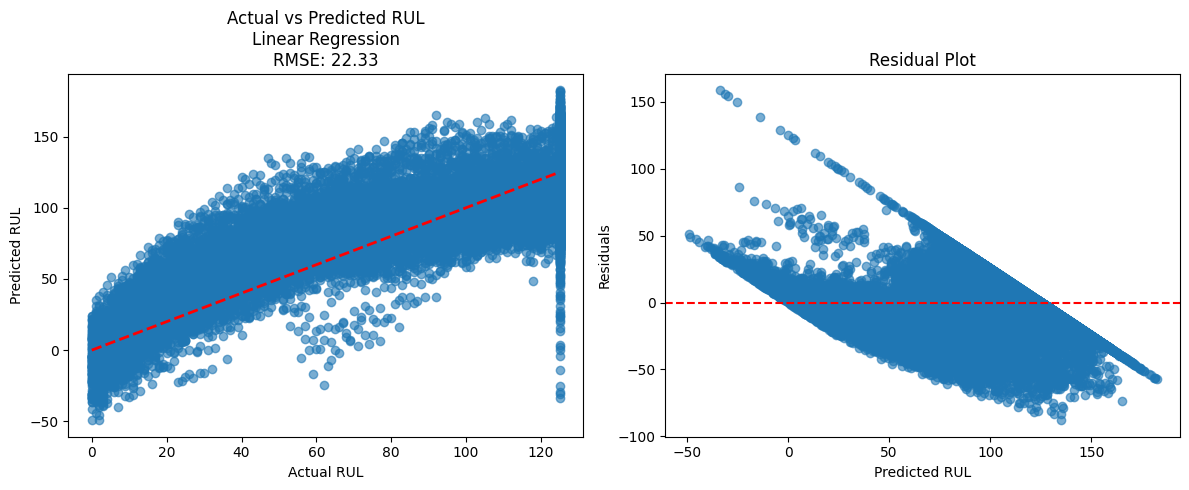

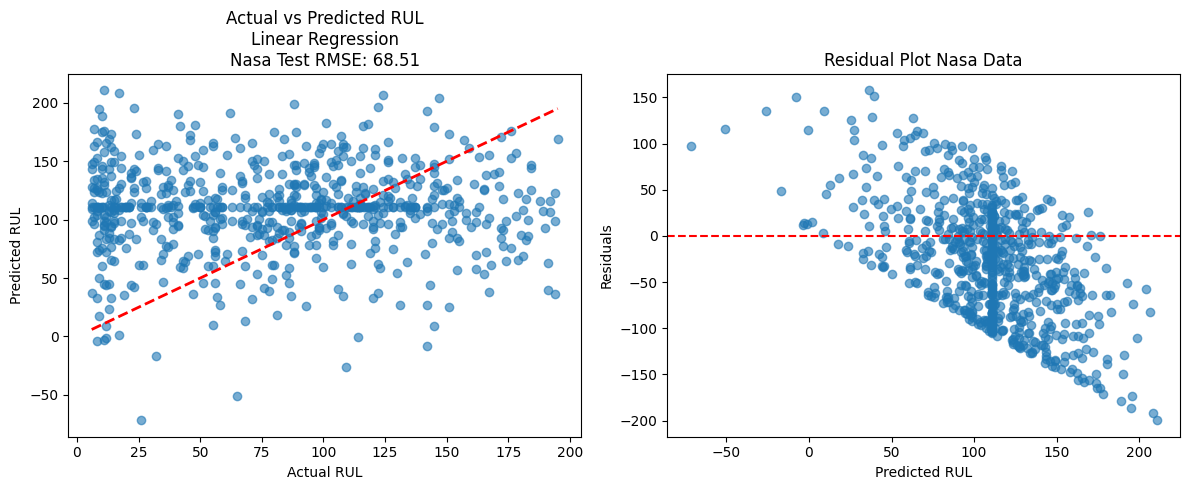


=== FEATURE IMPORTANCE (COEFFICIENTS) ===
Total features created: 54
Number of coefficients: 54

Top 10 Most Important Features:
       Feature  Coefficient
16     P30_std  -663.822802
30    phi_mean   543.405917
50   W31_slope   396.715632
28    Ps30_std   291.366132
20    Nf_slope   235.102739
18     Nf_mean   234.556190
48    W31_mean  -210.299909
29  Ps30_slope   178.462094
21     Nc_mean   177.435605
32   phi_slope  -160.313617


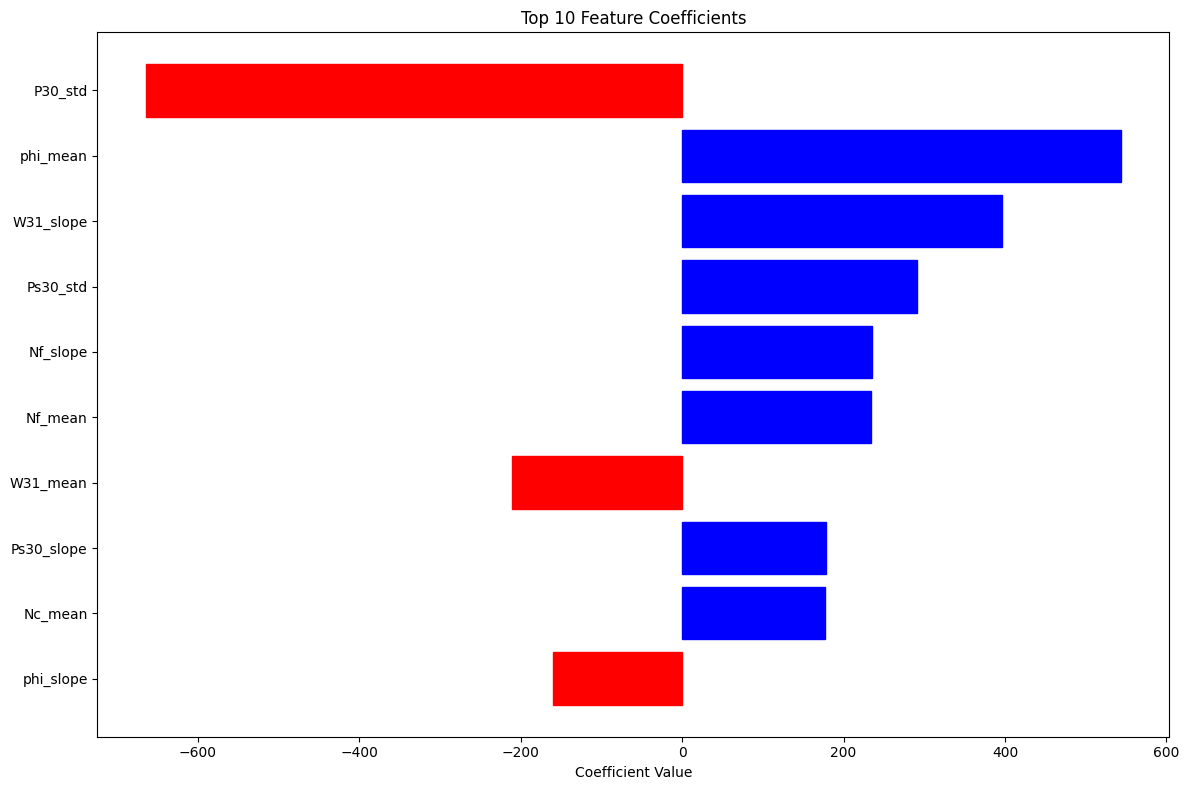

In [19]:
# Visualize results
import matplotlib.pyplot as plt

# Plot actual vs predicted
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(results['y_test'], results['y_test_pred'], alpha=0.6)
plt.plot([results['y_test'].min(), results['y_test'].max()], 
         [results['y_test'].min(), results['y_test'].max()], 'r--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f"Actual vs Predicted RUL\nLinear Regression\nRMSE: {results['test_rmse']:.2f}")

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = results['y_test'] - results['y_test_pred']
plt.scatter(results['y_test_pred'], residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(12, 5))

# Plot 1: Nasa Test Data - Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(df_rul, results['y_nasa_test_pred'], alpha=0.6)
plt.plot([df_rul.min(), df_rul.max()], 
         [df_rul.min(), df_rul.max()], 'r--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f"Actual vs Predicted RUL\nLinear Regression\nNasa Test RMSE: {results['nasa_test_rmse']:.2f}")

# Plot 2: Nasa Test Data - Residuals
plt.subplot(1, 2, 2)
residuals = df_rul - results['y_nasa_test_pred']
plt.scatter(results['y_nasa_test_pred'], residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals')
plt.title('Residual Plot Nasa Data')

plt.tight_layout()
plt.show()

# Show feature importance (coefficients)
print('\n=== FEATURE IMPORTANCE (COEFFICIENTS) ===')
coefficients = results['model'].coef_

# Create feature names dynamically based on the actual data structure
feature_names = []

# Filter out the excluded features
excluded_features = ['T2', 'P2', 'Nf_dmd', 'PCNfR_dmd', 'Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number']
available_features = [s for s in columns if s not in excluded_features]

# Create feature names based on available features
for feature in available_features:
    feature_names.extend([f"{feature}_mean", f"{feature}_std", f"{feature}_slope"])

print(f'Total features created: {len(feature_names)}')
print(f'Number of coefficients: {len(coefficients)}')

# Check if lengths match
if len(feature_names) == len(coefficients):
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print('\nTop 10 Most Important Features:')
    print(feature_importance_df.head(10))
    
    # Plot top 15 feature coefficients
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(10)
    bars = plt.barh(range(len(top_features)), top_features['Coefficient'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Coefficient Value')
    plt.title('Top 10 Feature Coefficients')
    plt.gca().invert_yaxis()

    # Color bars based on coefficient sign
    for i, (bar, coef) in enumerate(zip(bars, top_features['Coefficient'])):
        bar.set_color('red' if coef < 0 else 'blue')

    plt.tight_layout()
    plt.show()